In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

BASE_DIR = "/content/drive/MyDrive/ROI_Endoscopy_Paper/hyper_kvasir_subset"
VIDEO_DIR = os.path.join(BASE_DIR, "videos")
CSV_PATH  = os.path.join(BASE_DIR, "video-labels.csv")

assert os.path.exists(VIDEO_DIR), "Video directory not found"
assert os.path.exists(CSV_PATH), "video-labels.csv not found"

In [3]:
import pandas as pd

df = pd.read_csv(CSV_PATH)
print(df.head())
print("Total labeled videos:", len(df))

                             Video file     Organ    Finding 1  \
0  44f1e701-2d9a-4f25-a5a8-424bb549844d  Lower GI  anastomosis   
1  8f9e4085-98c4-4f69-99e6-3945dda43c05  Lower GI  anastomosis   
2  b85566cc-a3da-4044-b98c-43732ae5dd0b  Lower GI  anastomosis   
3  f918a7be-5bcb-47b1-8a4a-d93f33e9e5f5  Lower GI  anastomosis   
4  cafa734d-74ea-48f2-b58a-3f3151a99177  Lower GI  anastomosis   

        Classification 1 Detailed description of finding  \
0  Pathological findings                             NaN   
1  Pathological findings                             NaN   
2  Pathological findings                             NaN   
3  Pathological findings                             NaN   
4  Pathological findings                             NaN   

                         Finding 2           Classification 2  
0                              NaN                        NaN  
1                            stent  Therapeutic interventions  
2                              NaN                

In [4]:
import pandas as pd

df = pd.read_csv(CSV_PATH)

TARGET_FINDINGS = {
    "polyps": "polyp",
    "esophagitis": "lesion",
    "colitis": "inflammation",
    "ulcer": "inflammation",
    "bbps 2-3": "normal"
}

df["Finding 1"] = df["Finding 1"].str.lower().str.strip()

df_filtered = df[df["Finding 1"].isin(TARGET_FINDINGS.keys())]

print("Filtered video counts:")
print(df_filtered["Finding 1"].value_counts())


Filtered video counts:
Finding 1
polyps         77
bbps 2-3       31
ulcer          17
colitis        15
esophagitis     3
Name: count, dtype: int64


In [5]:
print(df_filtered[["Video file", "Finding 1"]].head())

                              Video file Finding 1
10  f1dfa843-1e53-4a5d-b3b1-d29dc08e968a  bbps 2-3
11  c205ec73-4652-4f91-8711-ddb6a50e1d16  bbps 2-3
12  31573497-b434-4c27-86ba-a53a65d5f9ce  bbps 2-3
13  da5d2629-3a74-4ec0-9ace-57dbc6ebddad  bbps 2-3
14  17241dcf-de85-461d-9435-f5134035aacb  bbps 2-3


In [6]:
import os

video_label_map = {}

for _, row in df_filtered.iterrows():
    video_name = row["Video file"]

    # add extension if missing
    if not video_name.endswith(".mp4"):
        video_name = video_name + ".mp4"

    video_label_map[video_name] = TARGET_FINDINGS[row["Finding 1"]]

print("Total mapped videos:", len(video_label_map))

Total mapped videos: 143


In [7]:
available_videos = set(os.listdir(VIDEO_DIR))

matched_videos = {
    v: c for v, c in video_label_map.items() if v in available_videos
}

print("Videos listed in CSV:", len(video_label_map))
print("Videos found in Drive:", len(matched_videos))

Videos listed in CSV: 143
Videos found in Drive: 0


In [8]:
import os

files = os.listdir(VIDEO_DIR)
files[:10], len(files)

(['0220d11b-ab12-4b02-93ce-5d7c205c7043.avi',
  '07bf7341-7ddd-44a0-8b31-36842b8761fa.avi',
  '0ecac639-6e57-4bab-8281-9d6feebe9599.avi',
  '11305ea5-389a-46c8-95f3-94a1af84247d.avi',
  '16e7e461-a9a7-4b04-8d2c-155de3eb1c90.avi',
  '1f17e901-9ba3-4536-abfe-d6a9a039e983.avi',
  '1de3ef0f-d54d-49e3-98a1-a919c5552a64.avi',
  '2383d344-9474-448b-a0b3-f9aa173954cc.avi',
  '29ce8d04-c184-42fa-ac05-322d3a2d37bd.avi',
  '2b80a3ae-e457-484d-955f-c2295de44bff.avi'],
 35)

In [9]:
import os

available_videos = os.listdir(VIDEO_DIR)

matched_videos = {}

for _, row in df_filtered.iterrows():
    video_id = row["Video file"]          # UUID (no extension)
    label = TARGET_FINDINGS[row["Finding 1"]]

    for fname in available_videos:
        if fname.startswith(video_id):
            matched_videos[fname] = label
            break

print("Videos listed in CSV (filtered):", len(df_filtered))
print("Videos found in Drive:", len(available_videos))
print("Videos matched successfully:", len(matched_videos))

Videos listed in CSV (filtered): 143
Videos found in Drive: 35
Videos matched successfully: 34


In [10]:
import os

FRAME_DIR = os.path.join(BASE_DIR, "frames")
os.makedirs(FRAME_DIR, exist_ok=True)

for cls in set(matched_videos.values()):
    os.makedirs(os.path.join(FRAME_DIR, cls), exist_ok=True)

print("Frame directories:", os.listdir(FRAME_DIR))


Frame directories: ['polyp', 'inflammation', 'lesion', 'normal']


In [11]:
import cv2

def extract_frames(video_path, out_dir, fps=1):
    cap = cv2.VideoCapture(video_path)
    video_fps = cap.get(cv2.CAP_PROP_FPS)
    if video_fps <= 0:
        cap.release()
        return

    interval = max(int(video_fps // fps), 1)
    count, saved = 0, 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if count % interval == 0:
            cv2.imwrite(
                os.path.join(out_dir, f"frame_{saved:05d}.jpg"),
                frame
            )
            saved += 1

        count += 1

    cap.release()


In [ ]:
import numpy as np

def is_blurry(image, threshold=100):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var() < threshold


In [ ]:
import shutil

TEMP_DIR = os.path.join(BASE_DIR, "temp_frames")
os.makedirs(TEMP_DIR, exist_ok=True)

for video_file, cls in matched_videos.items():
    video_path = os.path.join(VIDEO_DIR, video_file)
    if not os.path.exists(video_path):
        continue

    # extract frames temporarily
    extract_frames(video_path, TEMP_DIR, fps=1)

    for img_name in os.listdir(TEMP_DIR):
        img_path = os.path.join(TEMP_DIR, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue

        if not is_blurry(img):
            final_name = f"{video_file}_{img_name}"
            shutil.move(
                img_path,
                os.path.join(FRAME_DIR, cls, final_name)
            )

    # clean temp dir
    for f in os.listdir(TEMP_DIR):
        os.remove(os.path.join(TEMP_DIR, f))

shutil.rmtree(TEMP_DIR)
print("Frame extraction and blur filtering completed.")


Frame extraction and blur filtering completed.


In [ ]:
import glob

print("Final frame counts:")
for cls in os.listdir(FRAME_DIR):
    count = len(glob.glob(os.path.join(FRAME_DIR, cls, "*.jpg")))
    print(f"{cls}: {count} frames")


Final frame counts:
polyp: 351 frames
inflammation: 294 frames
lesion: 126 frames
normal: 254 frames


This figure shows the distribution of extracted frames across different ROI categories, highlighting class imbalance inherent in medical endoscopy data.

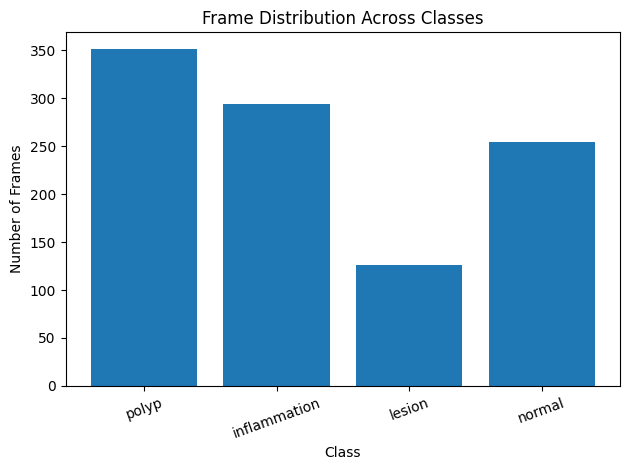

In [ ]:
import os
import matplotlib.pyplot as plt

FRAME_DIR = "/content/drive/MyDrive/ROI_Endoscopy_Paper/hyper_kvasir_subset/frames"

class_counts = {}
for cls in os.listdir(FRAME_DIR):
    class_counts[cls] = len(os.listdir(os.path.join(FRAME_DIR, cls)))

plt.figure()
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Class")
plt.ylabel("Number of Frames")
plt.title("Frame Distribution Across Classes")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


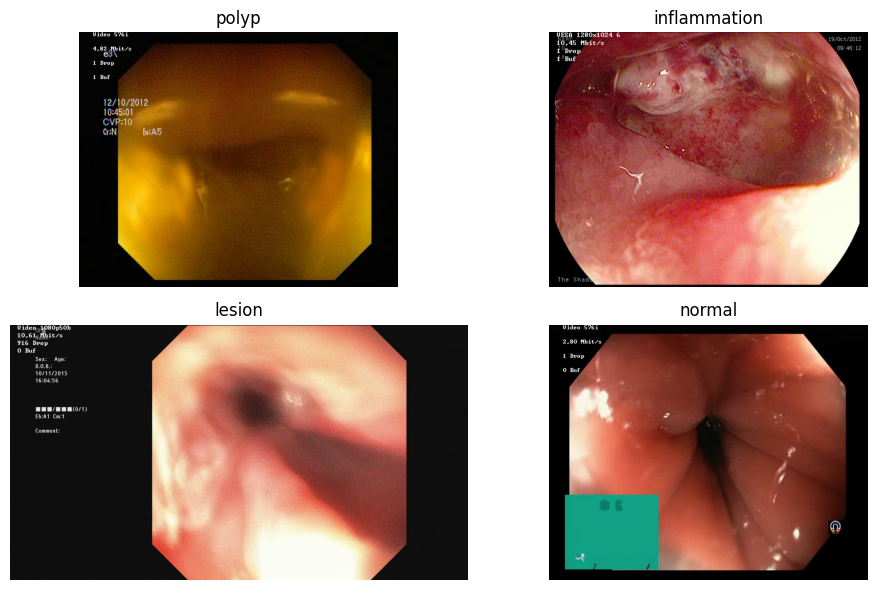

In [ ]:
import random
import cv2
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
i = 1

for cls in os.listdir(FRAME_DIR):
    cls_path = os.path.join(FRAME_DIR, cls)
    img_name = random.choice(os.listdir(cls_path))
    img = cv2.imread(os.path.join(cls_path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
    i += 1

plt.tight_layout()
plt.show()